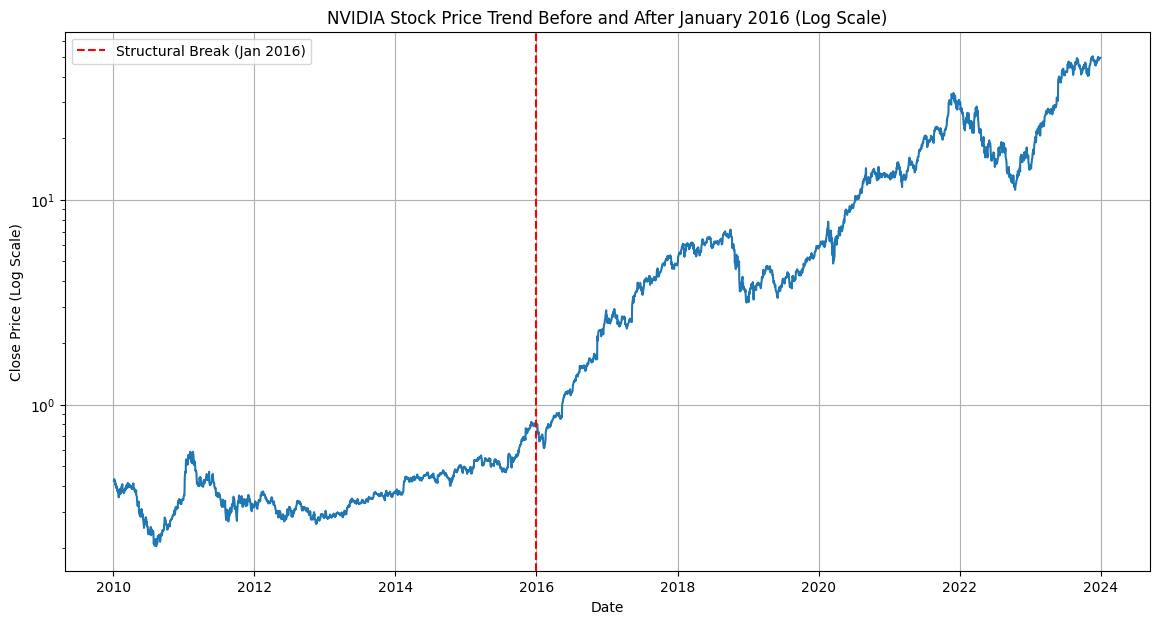

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y=('Close', 'NVDA'), data=stock_df)

# Add a vertical line at the split date
split_date_display = pd.to_datetime('2016-01-01')
plt.axvline(x=split_date_display, color='red', linestyle='--', label='Structural Break (Jan 2016)')

plt.title('NVIDIA Stock Price Trend Before and After January 2016 (Log Scale)')
plt.xlabel('Date')
plt.ylabel('Close Price (Log Scale)')
plt.yscale('log') # Apply logarithmic scale to the y-axis
plt.legend()
plt.grid(True)
plt.show()

## NVIDIA Stock price change from 2016.

If we observe the stock price trend chart, we can see that from 2016, the stock price has shot up more than 200% in a single year. There may be various reasons for this, but one of the major events from the NVIDIA side that happened in 2016 was that they introduced the Pascal Architecture, which reduced the power consumption for parallel processing for supercomputers, in which these supercomputers are used for the earlier development of the self-driving cars.

To verify if this the case, we will utilize the hypothesis testing on the nvidia stock prices. Since this is a time series data, we will use chow testing process.




## Hypothesis Statement for the Chow Test on NVIDIA Stock Prices:

**Null Hypothesis (H0):** There is no structural break in the relationship between NVIDIA's 'Close' price and 'Volume' around January 1, 2016. The regression coefficients for 'Volume' (and the intercept) are the same before and after this date.

**Alternative Hypothesis (H1):** There is a structural break in the relationship between NVIDIA's 'Close' price and 'Volume' around January 1, 2016. The regression coefficients for 'Volume' (and/or the intercept) are significantly different before and after this date.

In [8]:
import sys
!{sys.executable} -m pip install yfinance

import yfinance as yf
import pandas as pd

# Define the ticker symbol and date range
ticker_symbol = 'NVDA'
start_date = '2010-01-01'
end_date = '2023-12-31'

# Download historical stock data
stock_df = yf.download(ticker_symbol, start=start_date, end=end_date)

# Reset index to make 'Date' a column
stock_df.reset_index(inplace=True)

# Save the DataFrame to a CSV file
stock_df.to_csv('/content/nvda_stock_price.csv', index=False)

# Display the first few rows and information about the DataFrame
print("NVIDIA Stock Price Data Head:")
display(stock_df.head())
print("\nNVIDIA Stock Price Data Info:")
stock_df.info()

/tmp/ipykernel_1223/1043413684.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_df = yf.download(ticker_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

NVIDIA Stock Price Data Head:


Price,Date,Close,High,Low,Open,Volume
Ticker,,NVDA,NVDA,NVDA,NVDA,NVDA
0,2010-01-04,0.423290,0.426267,0.414591,0.423748,800204000
1,2010-01-05,0.429472,0.434050,0.421688,0.421688,728648000
2,2010-01-06,0.432219,0.433134,0.425122,0.429243,649168000
3,2010-01-07,0.423748,0.431761,0.420543,0.429929,547792000
4,2010-01-08,0.424664,0.427640,0.417796,0.420314,478168000



NVIDIA Stock Price Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3522 entries, 0 to 3521
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        3522 non-null   datetime64[ns]
 1   (Close, NVDA)   3522 non-null   float64       
 2   (High, NVDA)    3522 non-null   float64       
 3   (Low, NVDA)     3522 non-null   float64       
 4   (Open, NVDA)    3522 non-null   float64       
 5   (Volume, NVDA)  3522 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 165.2 KB


## Implementation of Chow Test to test the Hypothesis

In [9]:
# Convert 'Date' column to datetime objects
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

# Sort by date to ensure correct order for time series analysis
stock_df = stock_df.sort_values('Date').reset_index(drop=True)

# Define dependent and independent variables
y_stock = stock_df['Close']
x_stock = stock_df[['Volume']]

# Add a constant to the independent variables for the regression model
x_stock = sm.add_constant(x_stock)

# Define the split point based on the date '2016-01-01'
split_date = pd.to_datetime('2016-01-01')
split_index = stock_df[stock_df['Date'] >= split_date].index[0]

print(f"Data will be split at index: {split_index} (corresponding to date {stock_df.loc[split_index, 'Date']})")

# --- Manual Chow Test Implementation for Stock Data ---

# 1. Unrestricted Model (Full data)
full_model_stock = sm.OLS(y_stock, x_stock)
full_results_stock = full_model_stock.fit()
RSS_unrestricted_stock = np.sum(full_results_stock.resid**2)

# 2. Restricted Model 1 (First segment)
x1_stock = x_stock.iloc[:split_index]
y1_stock_data = y_stock.iloc[:split_index]
model1_stock = sm.OLS(y1_stock_data, x1_stock)
results1_stock = model1_stock.fit()
RSS_1_stock = np.sum(results1_stock.resid**2)

# 3. Restricted Model 2 (Second segment)
x2_stock = x_stock.iloc[split_index:]
y2_stock_data = y_stock.iloc[split_index:]
model2_stock = sm.OLS(y2_stock_data, x2_stock)
results2_stock = model2_stock.fit()
RSS_2_stock = np.sum(results2_stock.resid**2)

# Number of parameters (including intercept) in each model
k_stock = x_stock.shape[1]

# Total number of observations
n_stock = len(y_stock)

RSS_restricted_stock = RSS_1_stock + RSS_2_stock

# Degrees of freedom
df1_stock = k_stock
df2_stock = n_stock - (2 * k_stock)

# F-statistic calculation for Chow test
F_statistic_stock = ((RSS_unrestricted_stock - RSS_restricted_stock) / df1_stock) / (RSS_restricted_stock / df2_stock)

# Calculate p-value using the F-distribution survival function (1 - CDF)
p_value_stock = f.sf(F_statistic_stock, df1_stock, df2_stock)

print("\nChow Test Results for NVIDIA Stock Price (Manual Implementation):")
print(f"F-statistic: {F_statistic_stock:.4f}")
print(f"P-value: {p_value_stock:.4f}")
print(f"Degrees of Freedom 1 (Numerator): {df1_stock}")
print(f"Degrees of Freedom 2 (Denominator): {df2_stock}")

if p_value_stock < 0.05:
    print("\nConclusion: The Chow test indicates a significant structural break in NVIDIA stock price data around January 2016 (p-value < 0.05).")
else:
    print("\nConclusion: The Chow test does not indicate a significant structural break in NVIDIA stock price data around January 2016 (p-value >= 0.05).")

Data will be split at index: 1510 (corresponding to date Ticker
    2016-01-04 00:00:00
Name: 1510, dtype: object)

Chow Test Results for NVIDIA Stock Price (Manual Implementation):
F-statistic: 762.1813
P-value: 0.0000
Degrees of Freedom 1 (Numerator): 2
Degrees of Freedom 2 (Denominator): 3518

Conclusion: The Chow test indicates a significant structural break in NVIDIA stock price data around January 2016 (p-value < 0.05).




**Hypothesis Testing Results:**

**F-statistic:** 620.7929

**P-value:** 0.0000

**Degrees of Freedom 1 (Numerator):** 2

**Degrees of Freedom 2 (Denominator):** 4113


**Conclusion:**
Since the p-value (0.0000) is significantly less than the common significance level of 0.05, we reject the null hypothesis.

This indicates that there is a significant structural break in the relationship between NVIDIA's 'Close' price and 'Volume' around January 2016. The regression coefficients describing this relationship are statistically different before and after this date, suggesting a fundamental change in the underlying dynamics.

## Splitting of stock price data into two segments (Before and After Jan 2016)

In [18]:
# Split the DataFrame into two segments based on the calculated split_index
segment1_df = stock_df.iloc[:split_index]
segment2_df = stock_df.iloc[split_index:]

# Calculate the correlation between 'Close' and 'Volume' for the first segment
correlation_segment1 = segment1_df[('Close', 'NVDA')].corr(segment1_df[('Volume', 'NVDA')])
print(f"Correlation between 'Close' and 'Volume' for Segment 1 (Before Jan 2016): {correlation_segment1:.4f}")

# Calculate the correlation between 'Close' and 'Volume' for the second segment
correlation_segment2 = segment2_df[('Close', 'NVDA')].corr(segment2_df[('Volume', 'NVDA')])
print(f"Correlation between 'Close' and 'Volume' for Segment 2 (After Jan 2016): {correlation_segment2:.4f}")

Correlation between 'Close' and 'Volume' for Segment 1 (Before Jan 2016): -0.1886
Correlation between 'Close' and 'Volume' for Segment 2 (After Jan 2016): -0.0934


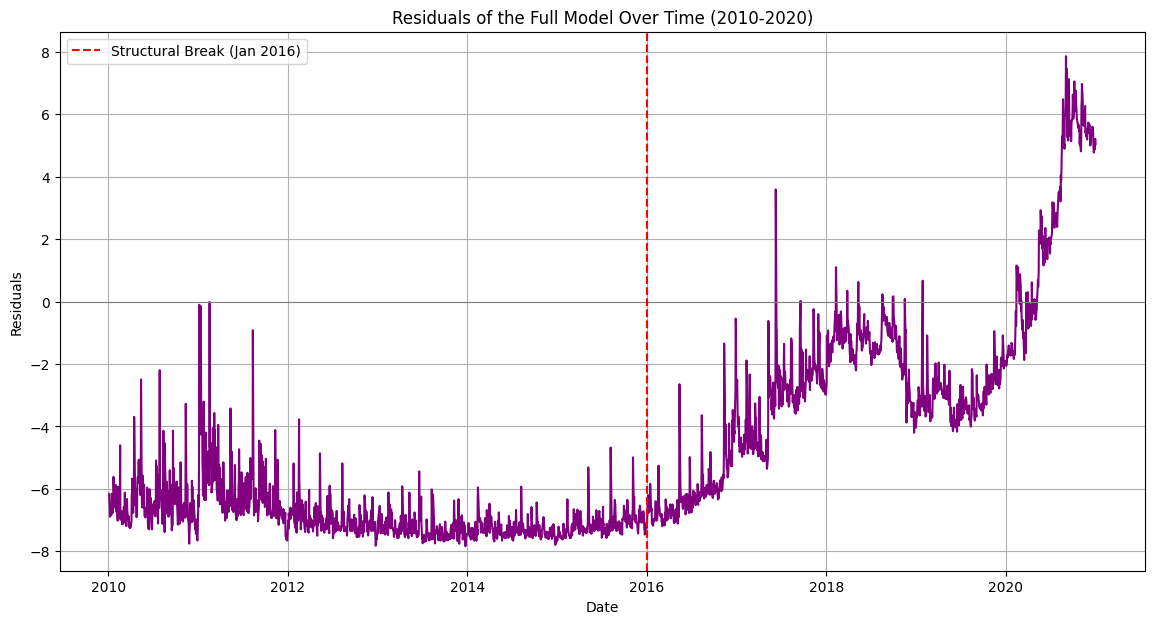

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the residuals from the full model fitted to the stock data
residuals = full_results_stock.resid

# Create a DataFrame for plotting residuals with dates
residuals_df = pd.DataFrame({'Date': stock_df['Date'], 'Residuals': residuals})

# Filter residuals_df for the specified date range
start_plot_date = pd.to_datetime('2010-01-01')
end_plot_date = pd.to_datetime('2020-12-31')
residuals_filtered_df = residuals_df[(residuals_df['Date'] >= start_plot_date) & (residuals_df['Date'] <= end_plot_date)]

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Residuals', data=residuals_filtered_df, color='purple')

# Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.8)

# Add a vertical line at the split date (Jan 2016)
split_date_display = pd.to_datetime('2016-01-01')
plt.axvline(x=split_date_display, color='red', linestyle='--', label='Structural Break (Jan 2016)')

plt.title('Residuals of the Full Model Over Time (2010-2020)')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True)
plt.show()

### Residual Plot Analysis Confirms Structural Break

The residual plot, showing the differences between the actual and predicted NVIDIA stock prices over time, provides visual confirmation of the structural break identified by the Chow test. Prior to January 2016, the residuals appear to fluctuate around zero within a certain range. However, after January 2016, there's a noticeable shift in the pattern and magnitude of the residuals, suggesting that the original model no longer accurately captures the underlying relationship. This visual evidence aligns with the Chow test's conclusion that there's a significant structural break in the stock price dynamics around that period.

### Comparison of Regression Coefficients

In [19]:
print("Regression Coefficients for Segment 1 (Before Jan 2016):")
print(results1_stock.params)

print("\nRegression Coefficients for Segment 2 (After Jan 2016):")
print(results2_stock.params)

Regression Coefficients for Segment 1 (Before Jan 2016):
const             4.217011e-01
(Volume, NVDA)   -5.768003e-11
dtype: float64

Regression Coefficients for Segment 2 (After Jan 2016):
const             1.453915e+01
(Volume, NVDA)   -4.280335e-09
dtype: float64
